### 06_identity_check
* Convert target image into embedding
    * Each image in `vggface2/probe` will be converted to template then compared with saved template of embeddings
    * Same for `vggface2/val` data
* Compare with stored embeddings using cosine similarity
    * Since templates of `vggface2/enroll` is already saved (probe is the 20% used for validation) --> should return Authorized/Accept
    * `vggface2/val` dataset has not been seen by the model --> should return Unauthorized/Reject


In [1]:
### 06_identity
# Evaluate identity verification against enrolled gallery:
# - Probes from `enroll` split (should be authorized)
# - Probes from `val` split (should be unauthorized / unseen)

from pathlib import Path
import numpy as np
import pandas as pd
import faiss
import matplotlib.pyplot as plt

import sys

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.build_templates import ID_COL  # "person_id"

DATA_ROOT = Path("../data_processed/vggface2")

# which gallery to use (pooled HQ)
GALLERY_NAME = "templates_all_enroll_hq"   
ID_COL = "person_id"


In [2]:
# ----- Helper functions -----

# ----- Load enrolled gallery -----
def load_gallery(DATA_ROOT, GALLERY_NAME):
    gallery_dir = DATA_ROOT / "enrolled_users"

    tpl_path = gallery_dir / f"{GALLERY_NAME}.npy"
    map_path = gallery_dir / f"{GALLERY_NAME}_map.csv"
    idx_path = gallery_dir / f"{GALLERY_NAME}.index"

    print("Gallery paths:")
    print("  templates:", tpl_path)
    print("  map:      ", map_path)
    print("  index:    ", idx_path)

    templates = np.load(tpl_path).astype(np.float32)
    templates_map = pd.read_csv(map_path)
    index = faiss.read_index(str(idx_path))

    print("Loaded gallery:", GALLERY_NAME)
    print("Templates shape:", templates.shape)
    print("Enrolled IDs:", templates_map[ID_COL].nunique())
    print(templates_map.head())

    enrolled_ids = set(templates_map[ID_COL].unique())
    return templates, templates_map, index, enrolled_ids

# ----- Load probe embeddings for enroll & val -----
def load_split(DATA_ROOT,split: str):
    """
    Loads embeddings and metadata for a probe split.
    Handles both:
       embeddings_map_with_pose_k5.csv
       embeddings_map.csv
    """
    emb_dir = DATA_ROOT / "embeddings" / split

    # Try pose-aware map first
    map_csv_pose = emb_dir / "embeddings_map_with_pose_k5.csv"
    map_csv_basic = emb_dir / "embeddings_map.csv"

    if map_csv_pose.exists():
        map_csv = map_csv_pose
    elif map_csv_basic.exists():
        map_csv = map_csv_basic
    else:
        raise FileNotFoundError(
            f"No embeddings_map file found in {emb_dir}"
        )

    emb_npy = emb_dir / "embeddings.npy"
    if not emb_npy.exists():
        raise FileNotFoundError(f"Missing embeddings.npy in {emb_dir}")

    df = pd.read_csv(map_csv)
    emb = np.load(emb_npy).astype(np.float32)

    print(f"[{split}] Loaded:")
    print("  map:", map_csv.name, "rows:", len(df))
    print("  embeddings:", emb.shape)

    return df, emb

# ----- Scoring helpers -----
def score_probe_embedding(probe_emb: np.ndarray):
    """
    Given a single probe embedding (D,), return:
      - best_score: max cosine similarity to any enrolled template
      - best_id: person_id of the template with best score
    """
    probe = probe_emb.astype(np.float32)
    probe /= np.linalg.norm(probe) + 1e-12
    probe = probe.reshape(1, -1)

    D, I = index.search(probe, k=1)  # 1-NN in the gallery
    best_score = float(D[0, 0])
    best_idx   = int(I[0, 0])
    best_id    = templates_map.iloc[best_idx][ID_COL]
    return best_score, best_id


def evaluate_split(df: pd.DataFrame,
                   emb_matrix: np.ndarray,
                   enrolled_ids: set,
                   split_name: str,
                   id_thresh: float):
    """
    Evaluate a probe split against the enrolled gallery.

    For each probe:
      - get its embedding
      - compute best_score, best_id
      - determine:
          y_true_auth = 1 if true identity is enrolled
                      = 0 otherwise
          y_pred_auth = 1 if best_score >= id_thresh
                      = 0 otherwise

    Returns:
      scores: np.ndarray (N,)
      y_true: np.ndarray (N,)
      y_pred: np.ndarray (N,)
    """
    scores = []
    y_true = []
    y_pred = []

    for _, row in df.iterrows():
        idx = int(row["embedding_index"])
        true_id = row[ID_COL]

        emb = emb_matrix[idx]
        best_score, _ = score_probe_embedding(emb)

        is_enrolled = 1 if true_id in enrolled_ids else 0
        is_pred_auth = 1 if best_score >= id_thresh else 0

        scores.append(best_score)
        y_true.append(is_enrolled)
        y_pred.append(is_pred_auth)

    scores = np.array(scores, dtype=np.float32)
    y_true = np.array(y_true, dtype=np.int32)
    y_pred = np.array(y_pred, dtype=np.int32)

    print(f"[{split_name}] evaluated {len(scores)} probes.")
    return scores, y_true, y_pred

# ----- Metrics helpers -----
def confusion(y_true, y_pred):
    TP = int(((y_true==1)&(y_pred==1)).sum())
    TN = int(((y_true==0)&(y_pred==0)).sum())
    FP = int(((y_true==0)&(y_pred==1)).sum())
    FN = int(((y_true==1)&(y_pred==0)).sum())
    return TP, FP, FN, TN

def metrics(TP, FP, FN, TN):
    acc = (TP + TN) / (TP + TN + FP + FN + 1e-12)
    prec = TP / (TP + FP + 1e-12)
    rec = TP / (TP + FN + 1e-12)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    return acc, prec, rec, f1




In [3]:

# probe splits
ENROLL_SPLIT = "enroll"   # should be enrolled identities
VAL_SPLIT    = "val"      # should be unseen identities
# ----- Identity decision threshold -----
# higher threshold = more strict
# Based on ROC analysis, threshold has been adjusted from 0.4 to 0.65
ID_THRESH = 0.65  # TODO: tune based on ROC / histograms

# load enrolled gallery
templates, templates_map, index, enrolled_ids = load_gallery(DATA_ROOT,GALLERY_NAME)

df_enroll, emb_enroll = load_split(DATA_ROOT, ENROLL_SPLIT)
df_val,    emb_val    = load_split(DATA_ROOT,VAL_SPLIT)

print("Unique identities in probes:", df_enroll[ID_COL].nunique())
print("Unique identities in val probes:", df_val[ID_COL].nunique())

# Enroll probes: should be authorized (y_true=1)
scores_enroll, y_enroll_true, y_enroll_pred = evaluate_split(
    df_enroll, emb_enroll, enrolled_ids, "enroll", ID_THRESH
)

# Val probes: should be unauthorized (y_true=0)
scores_val, y_val_true, y_val_pred = evaluate_split(
    df_val, emb_val, enrolled_ids, "val", ID_THRESH
)


Gallery paths:
  templates: ..\data_processed\vggface2\enrolled_users\templates_all_enroll_hq.npy
  map:       ..\data_processed\vggface2\enrolled_users\templates_all_enroll_hq_map.csv
  index:     ..\data_processed\vggface2\enrolled_users\templates_all_enroll_hq.index
Loaded gallery: templates_all_enroll_hq
Templates shape: (481, 512)
Enrolled IDs: 481
  person_id  template_index
0   n000002               0
1   n000003               1
2   n000004               2
3   n000005               3
4   n000006               4
[enroll] Loaded:
  map: embeddings_map_with_pose_k5.csv rows: 140922
  embeddings: (140922, 512)
[val] Loaded:
  map: embeddings_map.csv rows: 21295
  embeddings: (21295, 512)
Unique identities in probes: 480
Unique identities in val probes: 60
[enroll] evaluated 140922 probes.
[val] evaluated 21295 probes.


In [5]:


# Combine both splits into one big evaluation:
scores_all = np.concatenate([scores_enroll, scores_val], axis=0)
y_true_all = np.concatenate([y_enroll_true, y_val_true], axis=0)
y_pred_all = np.concatenate([y_enroll_pred, y_val_pred], axis=0)

TP, FP, FN, TN = confusion(y_true_all, y_pred_all)
acc, prec, rec, f1 = metrics(TP, FP, FN, TN)


print("=== ENROLL (should be authorized) ===")
TP_e, FP_e, FN_e, TN_e = confusion(y_enroll_true, y_enroll_pred)
acc_e, prec_e, rec_e, f1_e = metrics(TP_e, FP_e, FN_e, TN_e)
print(f"Accuracy:  {acc_e:.4f}")
print(f"Precision: {prec_e:.4f}")
print(f"Recall:    {rec_e:.4f}")
print(f"F1:        {f1_e:.4f}")

print("\n=== VAL (should be unauthorized) ===")
TP_v, FP_v, FN_v, TN_v = confusion(y_val_true, y_val_pred)
acc_v, prec_v, rec_v, f1_v = metrics(TP_v, FP_v, FN_v, TN_v)
print(f"Accuracy:  {acc_v:.4f}")
print(f"Precision: {prec_v:.4f}  (should be high → few false accepts)")
print(f"Recall:    {rec_v:.4f}")
print(f"F1:        {f1_v:.4f}")

print("=== Combined (enroll as positive, val as negative) ===")
print("TP (enrolled accepted): ", TP)
print("FP (val accepted):      ", FP)
print("FN (enrolled rejected): ", FN)
print("TN (val rejected):      ", TN)
print()
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")


=== ENROLL (should be authorized) ===
Accuracy:  0.8462
Precision: 1.0000
Recall:    0.8462
F1:        0.9167

=== VAL (should be unauthorized) ===
Accuracy:  0.8978
Precision: 0.0000  (should be high → few false accepts)
Recall:    0.0000
F1:        0.0000
=== Combined (enroll as positive, val as negative) ===
TP (enrolled accepted):  119251
FP (val accepted):       2176
FN (enrolled rejected):  21671
TN (val rejected):       19119

Accuracy:  0.8530
Precision: 0.9821
Recall:    0.8462
F1-score:  0.9091


In [6]:
overlap = set(df_enroll[ID_COL]).intersection(set(df_val[ID_COL]))
print("Number of overlapping identities:", len(overlap))
print("Overlapping identities:", list(overlap)[:20])


Number of overlapping identities: 0
Overlapping identities: []


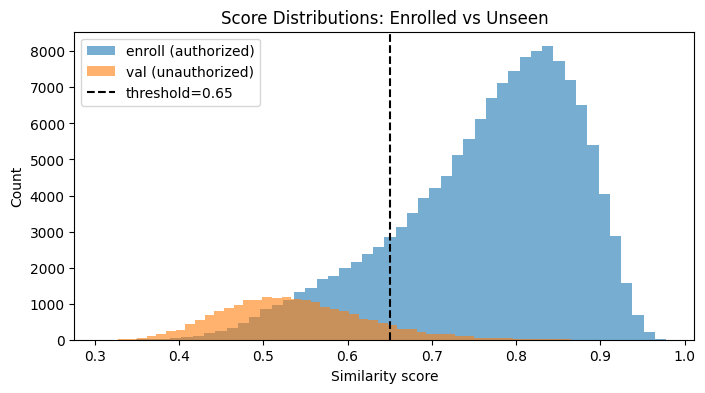

In [19]:
# Plot score histograms for threshold = 0.65
ID_THRESH = 0.65
import os
os.makedirs("../evaluation", exist_ok=True)

plt.figure(figsize=(8,4))
plt.hist(scores_enroll, bins=50, alpha=0.6, label="enroll (authorized)")
plt.hist(scores_val, bins=50, alpha=0.6, label="val (unauthorized)")
plt.axvline(ID_THRESH, color='black', linestyle='--', label=f"threshold={ID_THRESH}")
plt.xlabel("Similarity score")
plt.ylabel("Count")
plt.title("Score Distributions: Enrolled vs Unseen")
plt.legend()
plt.savefig("../evaluation/identity_score_histogram_65.png")
plt.show()


In [14]:
# Compute TAR @ FAR=1% by sweeping threshold
def compute_far_tar(scores_pos, scores_neg, th):
    # pos = enroll, neg = val
    tar = (scores_pos >= th).mean()   # True Accept Rate
    far = (scores_neg >= th).mean()   # False Accept Rate
    return tar, far

thresholds = np.linspace(0.4, 0.9, 51)
for th in thresholds:
    tar, far = compute_far_tar(scores_enroll, scores_val, th)
    if abs(far - 0.01) < 0.002:  # about 1% FAR
        print(f"th={th:.3f} → TAR={tar:.3f}, FAR={far:.3f}")


th=0.770 → TAR=0.558, FAR=0.011
th=0.780 → TAR=0.522, FAR=0.009


### Fine-tuning threshold
To get a better FAR score, we need to increase threshold from 0.65 to ~0.77

In [23]:
ID_THRESH = 0.75

# Enroll probes: should be authorized (y_true=1)
scores_enroll, y_enroll_true, y_enroll_pred = evaluate_split(
    df_enroll, emb_enroll, enrolled_ids, "enroll", ID_THRESH
)

# Val probes: should be unauthorized (y_true=0)
scores_val, y_val_true, y_val_pred = evaluate_split(
    df_val, emb_val, enrolled_ids, "val", ID_THRESH
)

[enroll] evaluated 140922 probes.
[val] evaluated 21295 probes.


In [22]:
# Combine both splits into one big evaluation:
scores_all_75 = np.concatenate([scores_enroll, scores_val], axis=0)
y_true_all_75 = np.concatenate([y_enroll_true, y_val_true], axis=0)
y_pred_all_75 = np.concatenate([y_enroll_pred, y_val_pred], axis=0)

TP, FP, FN, TN = confusion(y_true_all_75, y_pred_all_75)
acc, prec, rec, f1 = metrics(TP, FP, FN, TN)


print("=== ENROLL (should be authorized) ===")
TP_e, FP_e, FN_e, TN_e = confusion(y_enroll_true, y_enroll_pred)
acc_e, prec_e, rec_e, f1_e = metrics(TP_e, FP_e, FN_e, TN_e)
print(f"Accuracy:  {acc_e:.4f}")
print(f"Precision: {prec_e:.4f}")
print(f"Recall:    {rec_e:.4f}")
print(f"F1:        {f1_e:.4f}")

print("\n=== VAL (should be unauthorized) ===")
TP_v, FP_v, FN_v, TN_v = confusion(y_val_true, y_val_pred)
acc_v, prec_v, rec_v, f1_v = metrics(TP_v, FP_v, FN_v, TN_v)
print(f"Accuracy:  {acc_v:.4f}")
print(f"Precision: {prec_v:.4f}  (should be high → few false accepts)")
print(f"Recall:    {rec_v:.4f}")
print(f"F1:        {f1_v:.4f}")

print("=== Combined (enroll as positive, val as negative) ===")
print("TP (enrolled accepted): ", TP)
print("FP (val accepted):      ", FP)
print("FN (enrolled rejected): ", FN)
print("TN (val rejected):      ", TN)
print()
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

=== ENROLL (should be authorized) ===
Accuracy:  0.6243
Precision: 1.0000
Recall:    0.6243
F1:        0.7687

=== VAL (should be unauthorized) ===
Accuracy:  0.9841
Precision: 0.0000  (should be high → few false accepts)
Recall:    0.0000
F1:        0.0000
=== Combined (enroll as positive, val as negative) ===
TP (enrolled accepted):  87974
FP (val accepted):       338
FN (enrolled rejected):  52948
TN (val rejected):       20957

Accuracy:  0.6715
Precision: 0.9962
Recall:    0.6243
F1-score:  0.7675


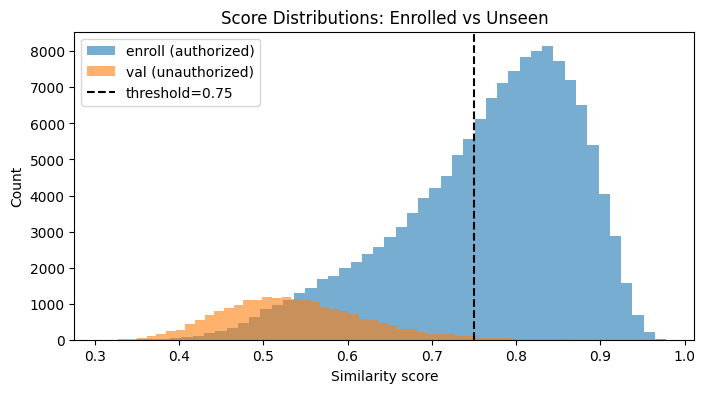

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot score histograms for threshold = 0.75
import os
os.makedirs("../evaluation", exist_ok=True)

plt.figure(figsize=(8,4))
plt.hist(scores_enroll, bins=50, alpha=0.6, label="enroll (authorized)")
plt.hist(scores_val, bins=50, alpha=0.6, label="val (unauthorized)")
plt.axvline(ID_THRESH, color='black', linestyle='--', label=f"threshold={ID_THRESH}")
plt.xlabel("Similarity score")
plt.ylabel("Count")
plt.title("Score Distributions: Enrolled vs Unseen")
plt.legend()
plt.savefig("../evaluation/identity_score_histogram_75.png")
plt.show()


In [ ]:
def compute_far_tar(scores_pos, scores_neg, th):
    tar = (scores_pos >= th).mean()   # True Accept Rate (enroll)
    far = (scores_neg >= th).mean()   # False Accept Rate (val)
    return tar, far

tar_065, far_065 = compute_far_tar(scores_enroll, scores_val, 0.65)
print(f"th=0.65 → TAR={tar_065:.3f}, FAR={far_065:.3f}")

tar_075, far_075 = compute_far_tar(scores_enroll, scores_val, 0.75)
print(f"th=0.65 → TAR={tar_075:.3f}, FAR={far_075:.3f}")

th=0.65 → TAR=0.846, FAR=0.102
th=0.65 → TAR=0.624, FAR=0.016


#### Analysis
FAR scores have improved drasically, but at the price of accuracy.
0.01% FAR may not be possible.

=== ENROLL (should be authorized) ===

| Metric    | **0.65** | **0.75** |
|-----------|---------:|---------:|
| Accuracy  | 0.8462   | 0.6243   |
| Precision | 1.0000   | 1.0000   |
| Recall    | 0.8462   | 0.6243   |
| F1        | 0.9167   | 0.7687   |
| TAR       | 0.846    | 0.624    |
| FAR       | 0.102    | 0.016    |


=== VAL (should be unauthorized) ===
| Metric    | **0.65** | **0.75** |
|-----------|---------:|---------:|
| Accuracy  | 0.8978   | 0.9841   |
| Precision | 0.0000   | 0.0000   |
| Recall    | 0.0000   | 0.0000   |
| F1        | 0.0000   | 0.0000   |


=== Combined (enroll as positive, val as negative) ===
| Metric    | **0.65** | **0.75** |
|-----------|---------:|---------:|
| TP        | 119251   | 87974    |
| FP        | 2176     | 338      |
| FN        | 21671    | 52948    |
| TN        |  19119   | 20957    |
| Accuracy  | 0.8530   | 0.6715   |
| Precision | 0.9821   | 0.9962   |
| Recall    | 0.8462   | 0.6243   |
| F1        | 0.9091   | 0.7675   |

In [4]:
# avg of 0.65 and 0.75
ID_THRESH = 0.70

# Enroll probes: should be authorized (y_true=1)
scores_enroll, y_enroll_true, y_enroll_pred = evaluate_split(
    df_enroll, emb_enroll, enrolled_ids, "enroll", ID_THRESH
)

# Val probes: should be unauthorized (y_true=0)
scores_val, y_val_true, y_val_pred = evaluate_split(
    df_val, emb_val, enrolled_ids, "val", ID_THRESH
)



[enroll] evaluated 140922 probes.
[val] evaluated 21295 probes.


In [49]:
# Combine both splits into one big evaluation:
scores_all_75 = np.concatenate([scores_enroll, scores_val], axis=0)
y_true_all_75 = np.concatenate([y_enroll_true, y_val_true], axis=0)
y_pred_all_75 = np.concatenate([y_enroll_pred, y_val_pred], axis=0)

TP, FP, FN, TN = confusion(y_true_all_75, y_pred_all_75)
acc, prec, rec, f1 = metrics(TP, FP, FN, TN)


print("=== ENROLL (should be authorized) ===")
TP_e, FP_e, FN_e, TN_e = confusion(y_enroll_true, y_enroll_pred)
acc_e, prec_e, rec_e, f1_e = metrics(TP_e, FP_e, FN_e, TN_e)
print(f"Accuracy:  {acc_e:.4f}")
print(f"Precision: {prec_e:.4f}")
print(f"Recall:    {rec_e:.4f}")
print(f"F1:        {f1_e:.4f}")

print("\n=== VAL (should be unauthorized) ===")
TP_v, FP_v, FN_v, TN_v = confusion(y_val_true, y_val_pred)
acc_v, prec_v, rec_v, f1_v = metrics(TP_v, FP_v, FN_v, TN_v)
print(f"Accuracy:  {acc_v:.4f}")
print(f"Precision: {prec_v:.4f}  (should be high → few false accepts)")
print(f"Recall:    {rec_v:.4f}")
print(f"F1:        {f1_v:.4f}")

print("=== Combined (enroll as positive, val as negative) ===")
print("TP (enrolled accepted): ", TP)
print("FP (val accepted):      ", FP)
print("FN (enrolled rejected): ", FN)
print("TN (val rejected):      ", TN)
print()
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

=== ENROLL (should be authorized) ===
Accuracy:  0.7541
Precision: 1.0000
Recall:    0.7541
F1:        0.8598

=== VAL (should be unauthorized) ===
Accuracy:  0.9559
Precision: 0.0000  (should be high → few false accepts)
Recall:    0.0000
F1:        0.0000
=== Combined (enroll as positive, val as negative) ===
TP (enrolled accepted):  106267
FP (val accepted):       939
FN (enrolled rejected):  34655
TN (val rejected):       20356

Accuracy:  0.7806
Precision: 0.9912
Recall:    0.7541
F1-score:  0.8565


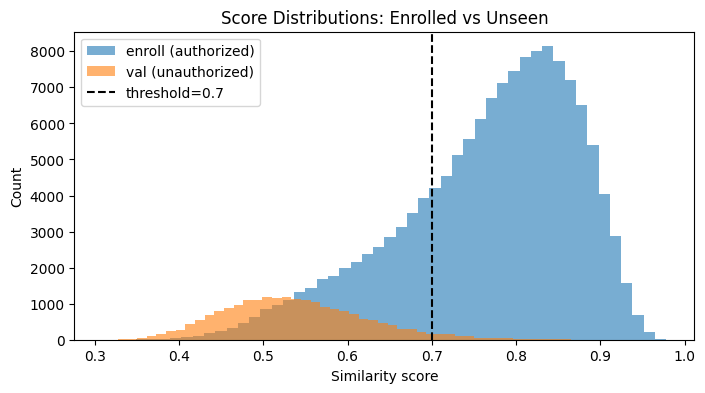

In [24]:
# Plot score histograms for threshold = 0.70
import os
os.makedirs("../evaluation", exist_ok=True)


plt.figure(figsize=(8,4))
plt.hist(scores_enroll, bins=50, alpha=0.6, label="enroll (authorized)")
plt.hist(scores_val, bins=50, alpha=0.6, label="val (unauthorized)")
plt.axvline(ID_THRESH, color='black', linestyle='--', label=f"threshold={ID_THRESH}")
plt.xlabel("Similarity score")
plt.ylabel("Count")
plt.title("Score Distributions: Enrolled vs Unseen")
plt.legend()
plt.savefig("../evaluation/identity_score_histogram_70.png")
plt.show()


### Overall Diagnostic
* ROC Curve
* TAR-FAR Table
* TAR-FAR Thresholds Graph

In [6]:
# Compute ROC curve
def compute_roc(scores_pos, scores_neg, thresholds):
    tprs, fprs = [], []
    for th in thresholds:
        # True Accept Rate
        tpr = (scores_pos >= th).mean()
        # False Accept Rate
        fpr = (scores_neg >= th).mean()
        tprs.append(tpr)
        fprs.append(fpr)
    return np.array(fprs), np.array(tprs)

thresholds = np.linspace(0.0, 1.0, 500)
fprs, tprs = compute_roc(scores_enroll, scores_val, thresholds)


In [7]:
# table of TAR @ FAR for selected thresholds
def tar_far_at(th):
    tar = (scores_enroll >= th).mean()
    far = (scores_val >= th).mean()
    return tar, far

ths = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.77, 0.80]

rows = []
for th in ths:
    tar, far = tar_far_at(th)
    rows.append((th, tar, far))

df_tar_far = pd.DataFrame(rows, columns=["Threshold", "TAR", "FAR"])
df_tar_far


,Threshold,TAR,FAR
0,0.50,0.983324,0.648368
1,0.55,0.954713,0.410613
2,0.60,0.909801,0.219676
3,0.65,0.846220,0.102184
4,0.70,0.754084,0.044095
5,0.75,0.624274,0.015872
6,0.77,0.558415,0.011082
7,0.80,0.444735,0.005353


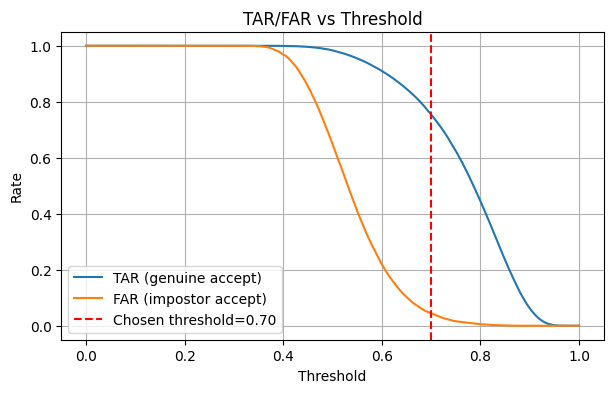

In [9]:
# Plot TAR/FAR vs Threshold 
plt.figure(figsize=(7,4))
plt.plot(thresholds, tprs, label="TAR (genuine accept)")
plt.plot(thresholds, fprs, label="FAR (impostor accept)")
plt.axvline(0.70, color='red', linestyle='--', label="Chosen threshold=0.70")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("TAR/FAR vs Threshold")
plt.legend()
plt.grid(True)
plt.savefig("../evaluation/identity_tar_far_vs_threshold_70.png")
plt.show()


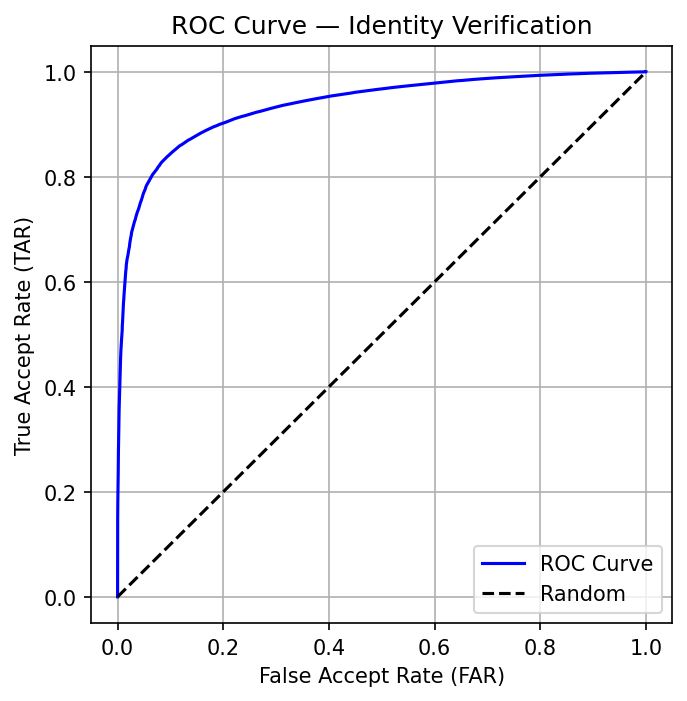

In [10]:

plt.figure(figsize=(5,5), dpi=150)
plt.plot(fprs, tprs, label="ROC Curve", color="blue")
plt.plot([0,1], [0,1], 'k--', label="Random")
plt.xlabel("False Accept Rate (FAR)")
plt.ylabel("True Accept Rate (TAR)")
plt.title("ROC Curve — Identity Verification")
plt.grid(True)
plt.legend()
plt.savefig("../evaluation/identity_roc_curve.png")
plt.show()

In [25]:
#======== Testing ==========

OUT_DIR = DATA_ROOT / "tester"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def load_split_map_emb(root: Path, split: str):
    emb_dir = root / "embeddings" / split
    # pick pose-aware map if present
    map_pose = emb_dir / "embeddings_map_with_pose_k5.csv"
    map_basic = emb_dir / "embeddings_map.csv"
    map_csv = map_pose if map_pose.exists() else map_basic
    if map_csv is None or not map_csv.exists():
        raise FileNotFoundError(f"No embeddings_map in {emb_dir}")
    df = pd.read_csv(map_csv)
    emb = np.load(emb_dir / "embeddings.npy").astype(np.float32)
    return df, emb

def make_tester_map_enough_val_and_small_enroll(sample_frac: float = 0.0002, seed: int = 42):
    df_val, emb_val = load_split_map_emb(DATA_ROOT, "val")
    df_enroll, emb_enroll = load_split_map_emb(DATA_ROOT, "enroll")

    # compute sample size (at least 1)
    n_enroll = len(df_enroll)
    sample_n = max(1, int(round(n_enroll * sample_frac)))

    sampled_df = df_enroll.sample(n=sample_n, random_state=seed)
    sampled_indices = sampled_df["embedding_index"].astype(int).values
    sampled_embs = emb_enroll[sampled_indices]

    # combine: all val first, then sampled enroll
    combined_map = pd.concat([df_val.reset_index(drop=True), sampled_df.reset_index(drop=True)], ignore_index=True)
    combined_embs = np.vstack([emb_val, sampled_embs])

    # rewrite embedding_index to point into combined_embs
    combined_map = combined_map.reset_index(drop=True)
    combined_map["embedding_index"] = combined_map.index.astype(int)

    # save
    csv_path = OUT_DIR / "tester_template_map.csv"
    npy_path = OUT_DIR / "tester_embeddings.npy"
    combined_map.to_csv(csv_path, index=False)
    np.save(npy_path, combined_embs.astype(np.float32))

    print(f"Saved tester map: {csv_path} ({len(combined_map)} rows)")
    print(f"Saved tester embeddings: {npy_path} (shape {combined_embs.shape})")
    print(f"Included enroll sample: {sample_n} of {n_enroll} ({sample_frac*100:.4f}%)")
    return combined_map, combined_embs

if __name__ == "__main__":
    # adjust sample_frac here if you want different percent
    make_tester_map_enough_val_and_small_enroll(sample_frac=0.3, seed=0)


Saved tester map: ..\data_processed\vggface2\tester\tester_template_map.csv (63572 rows)
Saved tester embeddings: ..\data_processed\vggface2\tester\tester_embeddings.npy (shape (63572, 512))
Included enroll sample: 42277 of 140922 (30.0000%)


Loaded tester map: ..\data_processed\vggface2\tester\tester_template_map.csv rows: 63572
Loaded tester embeddings: ..\data_processed\vggface2\tester\tester_embeddings.npy shape: (63572, 512)
[tester] evaluated 63572 probes.
=== TESTER SET ===
Rows: 63572  TP:31877 FP:939 FN:10400 TN:20356
Accuracy: 0.8216  Precision: 0.9714  Recall: 0.7540  F1: 0.8490


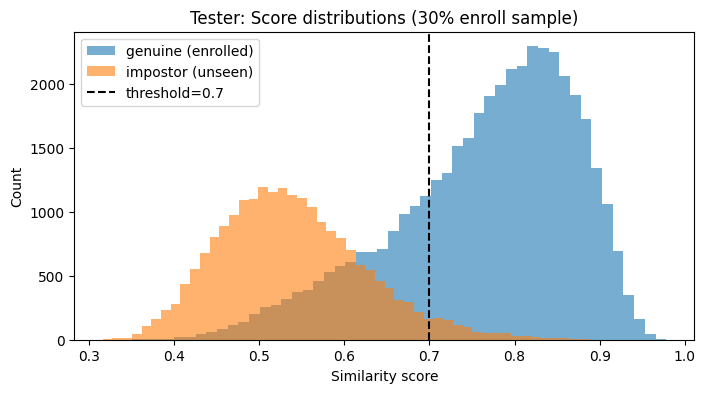

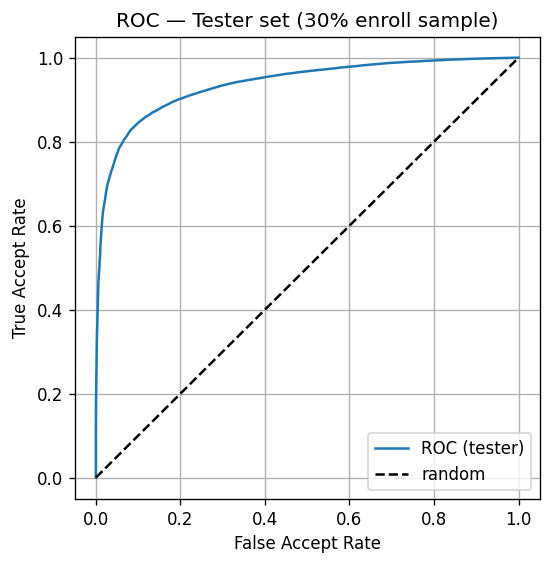

In [26]:
# Run evaluation on the tester set (all val + small enroll sample)
OUT_DIR = DATA_ROOT / "tester"
csv_path = OUT_DIR / "tester_template_map.csv"
npy_path = OUT_DIR / "tester_embeddings.npy"

assert csv_path.exists(), f"Missing {csv_path}"
assert npy_path.exists(), f"Missing {npy_path}"

df_tester = pd.read_csv(csv_path)
emb_tester = np.load(npy_path).astype(np.float32)
print("Loaded tester map:", csv_path, "rows:", len(df_tester))
print("Loaded tester embeddings:", npy_path, "shape:", emb_tester.shape)

# ensure embedding_index points into emb_tester
if df_tester["embedding_index"].max() >= len(emb_tester) or df_tester["embedding_index"].min() < 0:
    df_tester = df_tester.reset_index(drop=True)
    df_tester["embedding_index"] = df_tester.index.astype(int)

# evaluate
scores_t, y_t_true, y_t_pred = evaluate_split(df_tester, emb_tester, enrolled_ids, "tester", ID_THRESH)

TP, FP, FN, TN = confusion(y_t_true, y_t_pred)
acc, prec, rec, f1 = metrics(TP, FP, FN, TN)
print("=== TESTER SET ===")
print(f"Rows: {len(df_tester)}  TP:{TP} FP:{FP} FN:{FN} TN:{TN}")
print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")

# histograms
os.makedirs("../evaluation", exist_ok=True)

plt.figure(figsize=(8,4))
plt.hist(scores_t[y_t_true==1], bins=50, alpha=0.6, label="genuine (enrolled)")
plt.hist(scores_t[y_t_true==0], bins=50, alpha=0.6, label="impostor (unseen)")
plt.axvline(ID_THRESH, color='black', linestyle='--', label=f"threshold={ID_THRESH}")
plt.xlabel("Similarity score")
plt.ylabel("Count")
plt.title("Tester: Score distributions (30% enroll sample)")
plt.legend()
plt.savefig("../evaluation/identity_score_histogram_tester_30.png")
plt.show()

# ROC for tester
scores_pos = scores_t[y_t_true==1]
scores_neg = scores_t[y_t_true==0]
thresholds = np.linspace(0.0, 1.0, 500)
def compute_roc_local(pos, neg, thr):
    tprs, fprs = [], []
    for th in thr:
        tprs.append((pos >= th).mean() if len(pos)>0 else 0.0)
        fprs.append((neg >= th).mean() if len(neg)>0 else 0.0)
    return np.array(fprs), np.array(tprs)

fprs_t, tprs_t = compute_roc_local(scores_pos, scores_neg, thresholds)
plt.figure(figsize=(5,5), dpi=120)
plt.plot(fprs_t, tprs_t, label="ROC (tester)")
plt.plot([0,1],[0,1],'k--', label="random")
plt.xlabel("False Accept Rate")
plt.ylabel("True Accept Rate")
plt.title("ROC — Tester set (30% enroll sample)")
plt.grid(True)
plt.legend()
plt.savefig("../evaluation/identity_roc_curve_tester_30.png")
plt.show()


=== Sample frac: 40.00% ===
Saved tester map: ..\data_processed\vggface2\tester\tester_template_map.csv (77664 rows)
Saved tester embeddings: ..\data_processed\vggface2\tester\tester_embeddings.npy (shape (77664, 512))
Included enroll sample: 56369 of 140922 (40.0000%)
[tester_40] evaluated 77664 probes.
n_probes: 77664  positives: 56369  negatives: 21295  AUC ≈ 0.9368

=== Sample frac: 30.00% ===
Saved tester map: ..\data_processed\vggface2\tester\tester_template_map.csv (63572 rows)
Saved tester embeddings: ..\data_processed\vggface2\tester\tester_embeddings.npy (shape (63572, 512))
Included enroll sample: 42277 of 140922 (30.0000%)
[tester_30] evaluated 63572 probes.
n_probes: 63572  positives: 42277  negatives: 21295  AUC ≈ 0.9367

=== Sample frac: 80.00% ===
Saved tester map: ..\data_processed\vggface2\tester\tester_template_map.csv (134033 rows)
Saved tester embeddings: ..\data_processed\vggface2\tester\tester_embeddings.npy (shape (134033, 512))
Included enroll sample: 112738 o

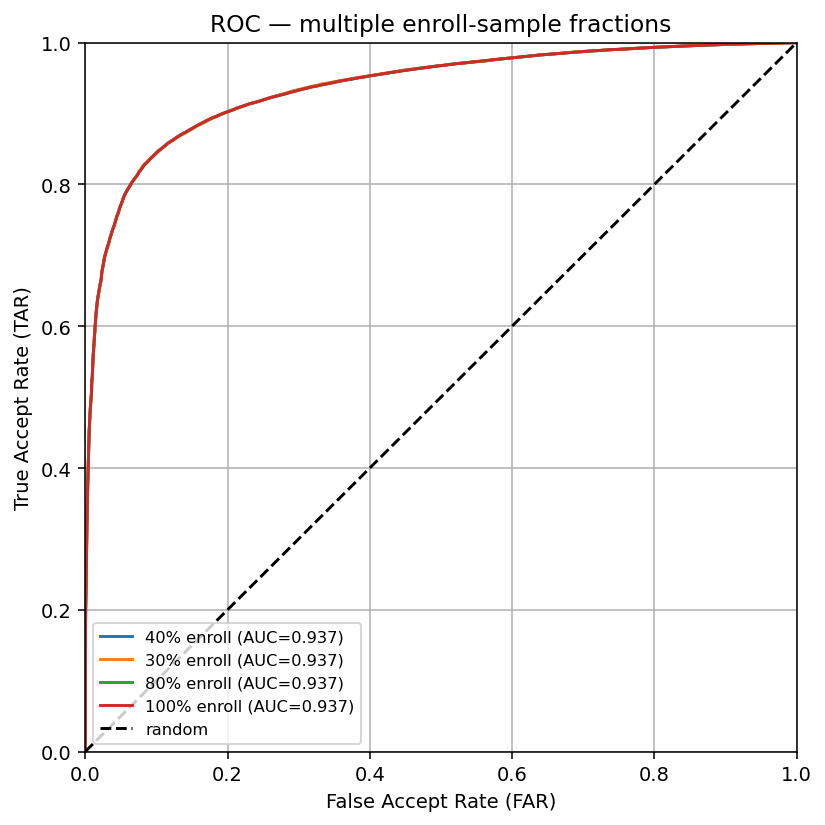

Saved ROC figure to: ..\evaluation\identity_roc_multi_samples_20251202_172044.png


In [31]:
# Build and plot ROC curves for several enroll-sample fractions (40%, 30%, 80%, 100%)
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

fractions = [0.4, 0.3, 0.8, 1.0]   # 40%, 30%, 80%, 100%
seed = 0
thresholds = np.linspace(0.0, 1.0, 501)

results = []

for frac in fractions:
    print(f"\n=== Sample frac: {frac:.2%} ===")
    df_tester, emb_tester = make_tester_map_enough_val_and_small_enroll(sample_frac=frac, seed=seed)
    scores_t, y_t_true, y_t_pred = evaluate_split(df_tester, emb_tester, enrolled_ids, f"tester_{int(frac*100)}", ID_THRESH)

    pos = scores_t[y_t_true == 1]
    neg = scores_t[y_t_true == 0]

    fprs = []
    tprs = []
    for th in thresholds:
        tprs.append((pos >= th).mean() if len(pos) > 0 else 0.0)
        fprs.append((neg >= th).mean() if len(neg) > 0 else 0.0)
    fprs = np.array(fprs)
    tprs = np.array(tprs)

    # approximate AUC (TAR vs FAR)
    try:
        from sklearn.metrics import auc
        auc_val = auc(fprs, tprs)
    except Exception:
        auc_val = np.trapz(tprs, fprs)

    print(f"n_probes: {len(scores_t)}  positives: {len(pos)}  negatives: {len(neg)}  AUC ≈ {auc_val:.4f}")

    results.append(dict(frac=frac, fprs=fprs, tprs=tprs, auc=auc_val))

# Plot combined ROC
plt.figure(figsize=(6,6), dpi=140)
for r in results:
    label = f"{int(r['frac']*100)}% enroll (AUC={r['auc']:.3f})"
    plt.plot(r['fprs'], r['tprs'], label=label)
plt.plot([0,1],[0,1],'k--', label="random")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("False Accept Rate (FAR)")
plt.ylabel("True Accept Rate (TAR)")
plt.title("ROC — multiple enroll-sample fractions")
plt.grid(True)
plt.legend(loc="lower left", fontsize="small")
plt.tight_layout()

out_dir = Path("../evaluation")
out_dir.mkdir(parents=True, exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
out_png = out_dir / f"identity_roc_multi_samples_{ts}.png"
plt.savefig(out_png)
plt.show()
print("Saved ROC figure to:", out_png)

### Testing with Defined set
Playing around with a tester set composed of:
* val users: unseen
* a percentage of saved user from enroll

We can see that the classifications all vary based on the percentage and results show that the match is working well with 0.7 threshold.
      
* At 40% enroll:      
    - Accuracy: 0.8103
    - Precision: 0.9784
    - Recall: 0.7554
    - F1: 0.8525
* At 80% enroll:      
    - Accuracy: 0.7863 
    - Precision: 0.9891 
    - Recall: 0.7542
    - F1: 0.8558
* At 100% enroll: 
    - Accuracy: 0.7806  
    - Precision: 0.9912  
    - Recall: 0.7541  
    - F1: 0.8565